In [ ]:
import os
import random
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from torchvision import transforms
from torchvision.datasets import ImageFolder


# **Custom Noise**

In [6]:
class AddNoise(object):
    def __init__(self, std=0.05):
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std
        return tensor + noise

# **Augmentation Function**

In [ ]:
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

def augment_image(img):
    augmented_images = []

    # Flip
    flip = img.transpose(Image.FLIP_LEFT_RIGHT)
    augmented_images.append(flip)

    # Rotation
    rotated = img.rotate(random.randint(-25, 25))
    augmented_images.append(rotated)

    # Brightness
    bright = ImageEnhance.Brightness(img).enhance(random.uniform(0.6, 1.8))
    augmented_images.append(bright)

    # Noise
    tensor = to_tensor(img)
    noise = tensor + torch.randn_like(tensor) * 0.05
    noise_img = to_pil(torch.clamp(noise, 0, 1))
    augmented_images.append(noise_img)

    return augmented_images

# **original dataset path**

In [ ]:
input_dir = "data/train"
output_dir = "data/train_augmented"

os.makedirs(output_dir, exist_ok=True)

classes = os.listdir(input_dir)

# **COUNT BEFORE AUGMENTATION**

In [ ]:
# =========================
before_counts = {}

for cls in classes:
    class_path = os.path.join(input_dir, cls)
    before_counts[cls] = len(os.listdir(class_path))

print("Dataset BEFORE Augmentation:", before_counts)

Dataset BEFORE Augmentation: {'WithMask': 5000, 'WithoutMask': 5000}

## **create Augmented dataset**

In [ ]:
after_counts = {}

for cls in classes:
    os.makedirs(os.path.join(output_dir, cls), exist_ok=True)

    class_path = os.path.join(input_dir, cls)
    img_list = os.listdir(class_path)

    count = 0

    for img_name in img_list:
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path).convert("RGB")

            # Save original
            img.save(os.path.join(output_dir, cls, f"orig_{img_name}"))
            count += 1

            # Generate augmented versions
            aug_images = augment_image(img)

            for i, aug_img in enumerate(aug_images):
                aug_img.save(os.path.join(output_dir, cls, f"aug_{i}_{img_name}"))
                count += 1

        except:
            pass

    after_counts[cls] = count

print("Augmented dataset created successfully!")
print("Dataset AFTER Augmentation:", after_counts)

Augmented dataset created successfully!

Dataset AFTER Augmentation: {'WithMask': 25000, 'WithoutMask': 25000}

# **LOAD NEW TRAINDATASET**

In [ ]:
train_dataset = ImageFolder("data/train_augmented")
val_dataset   = ImageFolder("data/val")

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Classes: ['WithMask', 'WithoutMask']

New Train Size: 50000

Validation Size: 800

# **VISUAL COMPARISON PLOT**

In [ ]:
import numpy as np

plt.figure(figsize=(10,5))

x = np.arange(len(before_counts))  # positions
width = 0.35

before_vals = list(before_counts.values())
after_vals = list(after_counts.values())

plt.bar(x - width/2, before_vals, width, label="Before Augmentation")
plt.bar(x + width/2, after_vals, width, label="After Augmentation")

plt.xticks(x, list(before_counts.keys()))

plt.title("Dataset Size Comparison (Before vs After Augmentation)")
plt.legend()
plt.show()

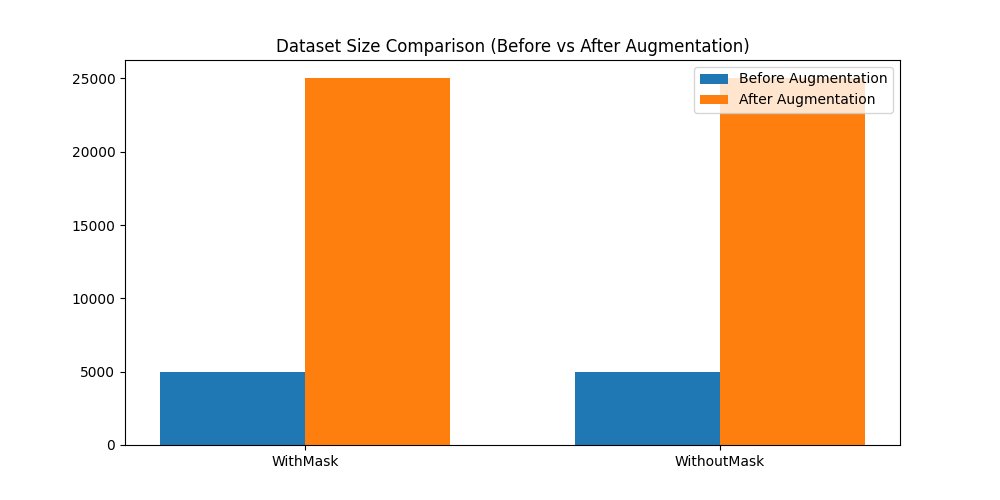

## **SHOW SAMPLES**

In [ ]:
import matplotlib.pyplot as plt

def show_samples():
    plt.figure(figsize=(12,5))

    for i in range(5):
        img_path = random.choice(train_dataset.samples)[0]
        img = Image.open(img_path).convert("RGB")

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle("Augmented Dataset Samples")
    plt.show()

show_samples()

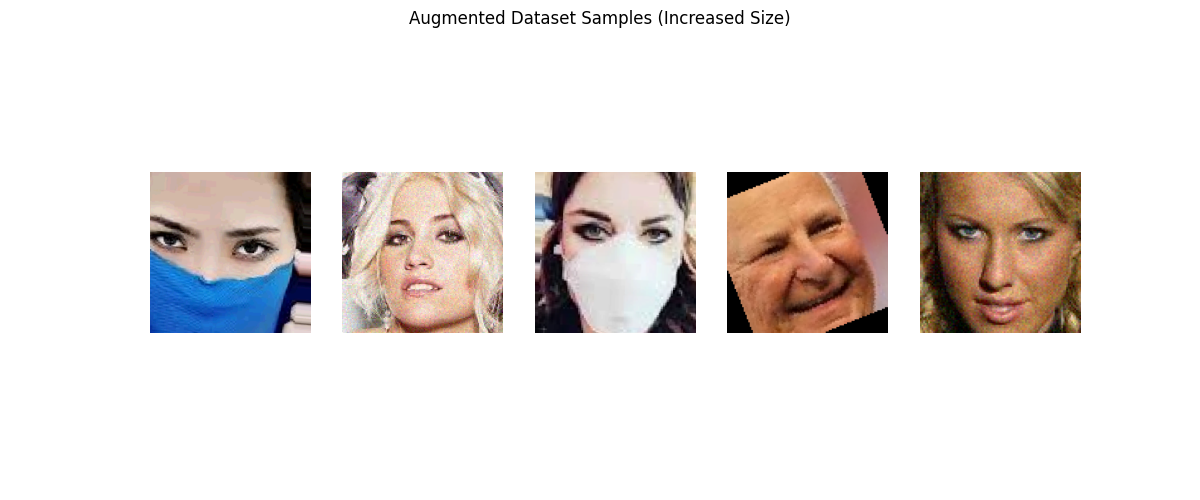